**Họ tên:** Chu Thị Bảo Ngọc\
**MSHV:** 22C01035

<hr style="border:1px solid black">

# <h1><center>**BÀI TẬP CUỐI KỲ**</center></h1>
## <h1><center>**Môn: Mạng nơ - ron và học sâu**</center></h1>

<hr style="border:1px solid black">

In [1]:
# Import libraries
import numpy as np
import tensorflow as tf
import keras

# Load the data, process and normalize the images

In [ ]:
# Load the cifar10 dataset and split train/test
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Split train/valid from the training set
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=5)

print("Train shape: X_train = " + str(X_train.shape) + ", y_train = " + str(y_train.shape))
print("Validation shape: X_val = " + str(X_val.shape) + ", y_val = " + str(y_val.shape))
print("Test shape: X_test = " + str(X_test.shape) + ", y_test = " + str(y_test.shape))

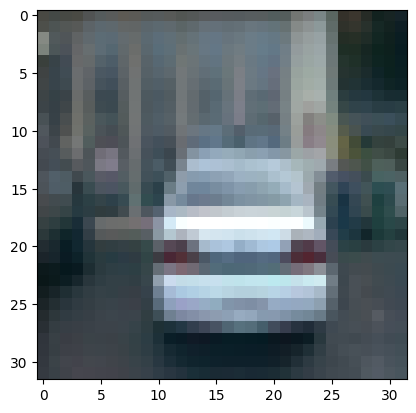

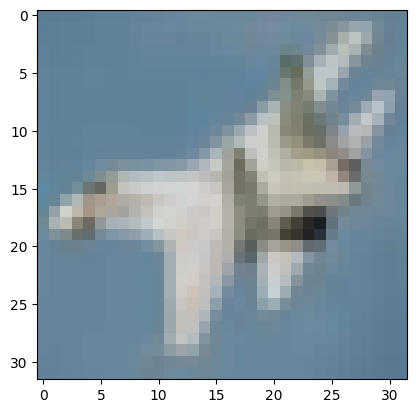

In [3]:
# Show some samples in the dataset
import matplotlib.pyplot as plt
imgplot = plt.imshow(X_train[5])
plt.show()
imgplot = plt.imshow(X_test[10])
plt.show()

In [4]:
# Normalize pixel values
X_train, X_val, X_test = X_train/255.0, X_val/255.0, X_test/255.0

## Build the model


In [5]:
# Import libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization

# Initialize my model as a Sequential model
my_model = Sequential(name='MyModel')

# Block 1
my_model.add(Conv2D(filters=64, input_shape=(32,32,3), kernel_size=(3,3), strides=(1,1), padding='same', kernel_regularizer=tf.keras.regularizers.L2(0.001), name='Block_1_Conv'))
my_model.add(Activation('relu'))

# Block 2
my_model.add(Conv2D(filters=64, input_shape=(32,32,3), kernel_size=(3,3), strides=(1,1), padding='same', kernel_regularizer=tf.keras.regularizers.L2(0.001), name='Block_2_Conv'))
my_model.add(Activation('relu'))

# Block 3
my_model.add(Conv2D(filters=128, input_shape=(32,32,3), kernel_size=(3,3), strides=(1,1), padding='same', kernel_regularizer=tf.keras.regularizers.L2(0.001), name='Block_3_Conv'))
my_model.add(Activation('relu'))
my_model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='same', name='Block_3_MaxPool'))
my_model.add(Dropout(rate=0.1))

# Block 4
my_model.add(Conv2D(filters=128, input_shape=(32,32,3), kernel_size=(3,3), strides=(1,1), padding='same', kernel_regularizer=tf.keras.regularizers.L2(0.001), name='Block_4_Conv'))
my_model.add(Activation('relu'))

# Block 5
my_model.add(Conv2D(filters=128, input_shape=(32,32,3), kernel_size=(3,3), strides=(1,1), padding='same', kernel_regularizer=tf.keras.regularizers.L2(0.001), name='Block_5_Conv'))
my_model.add(Activation('relu'))

# Block 6
my_model.add(Conv2D(filters=128, input_shape=(32,32,3), kernel_size=(3,3), strides=(1,1), padding='same', kernel_regularizer=tf.keras.regularizers.L2(0.001), name='Block_6_Conv'))
my_model.add(Activation('relu'))
my_model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='same', name='Block_6_MaxPool'))
my_model.add(Dropout(rate=0.1))

# Block 7
my_model.add(Conv2D(filters=256, input_shape=(32,32,3), kernel_size=(3,3), strides=(1,1), padding='same', kernel_regularizer=tf.keras.regularizers.L2(0.001), name='Block_7_Conv'))
my_model.add(Activation('relu'))

# Block 8
my_model.add(Conv2D(filters=256, input_shape=(32,32,3), kernel_size=(3,3), strides=(1,1), padding='same', kernel_regularizer=tf.keras.regularizers.L2(0.001), name='Block_8_Conv'))
my_model.add(Activation('relu'))
my_model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='same', name='Block_8_MaxPool'))
my_model.add(Dropout(rate=0.2))

# Block 9
my_model.add(Conv2D(filters=256, input_shape=(32,32,3), kernel_size=(3,3), strides=(1,1), padding='same', kernel_regularizer=tf.keras.regularizers.L2(0.001), name='Block_9_Conv'))
my_model.add(Activation('relu'))
my_model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='same', name='Block_9_MaxPool'))
my_model.add(Dropout(rate=0.3))

# Block 10
my_model.add(Conv2D(filters=256, input_shape=(32,32,3), kernel_size=(3,3), strides=(1,1), padding='same', kernel_regularizer=tf.keras.regularizers.L2(0.001), name='Block_10_Conv'))
my_model.add(Activation('relu'))
my_model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='same', name='Block_10_MaxPool'))
my_model.add(Dropout(rate=0.3))

# Flatten
my_model.add(Flatten())

# Fully connected (FC) layer 1
my_model.add(Dense(1024, kernel_regularizer=tf.keras.regularizers.L2(0.001)))
my_model.add(BatchNormalization())
my_model.add(Activation('relu'))
my_model.add(Dropout(rate=0.4))

# Fully connected (FC) layer 2
my_model.add(Dense(10))
my_model.add(Activation('softmax'))

# Model Summary
my_model.summary()

Model: "MyModel"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Block_1_Conv (Conv2D)       (None, 32, 32, 64)        1792      
                                                                 
 activation (Activation)     (None, 32, 32, 64)        0         
                                                                 
 Block_2_Conv (Conv2D)       (None, 32, 32, 64)        36928     
                                                                 
 activation_1 (Activation)   (None, 32, 32, 64)        0         
                                                                 
 Block_3_Conv (Conv2D)       (None, 32, 32, 128)       73856     
                                                                 
 activation_2 (Activation)   (None, 32, 32, 128)       0         
                                                                 
 Block_3_MaxPool (MaxPoolin  (None, 16, 16, 128)       0   

In [6]:
# Compile the model
opt = tf.keras.optimizers.SGD(learning_rate=0.001, momentum=0.9)
my_model.compile(optimizer=opt, loss= tf.keras.losses.sparse_categorical_crossentropy, metrics=['accuracy'])

# Train the model

In [7]:
# Create a callback ReduceLROnPlateau. This callback will reduce the learning rate whenever the monitered value stops improving
rlr = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", mode="min", verbose=0, factor=0.6, patience=2)

# Create a callback ModelCheckpoint. This callback will save the model when finding one better than the current best
mc = keras.callbacks.ModelCheckpoint(filepath="epoch-{epoch:02d}.hdf5", monitor='val_loss', mode='min', verbose=0, save_best_only=True)

# Train the model. Using Colab for training
history = my_model.fit(X_train, y_train, batch_size=64, epochs=30, validation_data=(X_val, y_val), callbacks=[rlr, mc])

Epoch 1/30
704/704 [==============================] - 37s 34ms/step - loss: 4.0021 - accuracy: 0.1712 - val_loss: 3.7841 - val_accuracy: 0.2472 - lr: 0.0010
Epoch 2/30
  1/704 [..............................] - ETA: 21s - loss: 3.7027 - accuracy: 0.3125

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


704/704 [==============================] - 22s 32ms/step - loss: 3.6968 - accuracy: 0.2566 - val_loss: 3.4842 - val_accuracy: 0.3466 - lr: 0.0010
Epoch 3/30
704/704 [==============================] - 22s 32ms/step - loss: 3.4904 - accuracy: 0.3340 - val_loss: 3.4167 - val_accuracy: 0.3808 - lr: 0.0010
Epoch 4/30
704/704 [==============================] - 22s 31ms/step - loss: 3.2979 - accuracy: 0.4091 - val_loss: 3.3314 - val_accuracy: 0.4168 - lr: 0.0010
Epoch 5/30
704/704 [==============================] - 22s 31ms/step - loss: 3.1160 - accuracy: 0.4701 - val_loss: 3.0729 - val_accuracy: 0.4752 - lr: 0.0010
Epoch 6/30
704/704 [==============================] - 22s 32ms/step - loss: 2.9577 - accuracy: 0.5123 - val_loss: 2.8784 - val_accuracy: 0.5468 - lr: 0.0010
Epoch 7/30
704/704 [==============================] - 22s 31ms/step - loss: 2.8115 - accuracy: 0.5557 - val_loss: 2.7990 - val_accuracy: 0.5522 - lr: 0.0010
Epoch 8/30
704/704 [==============================] - 22s 31ms/step -

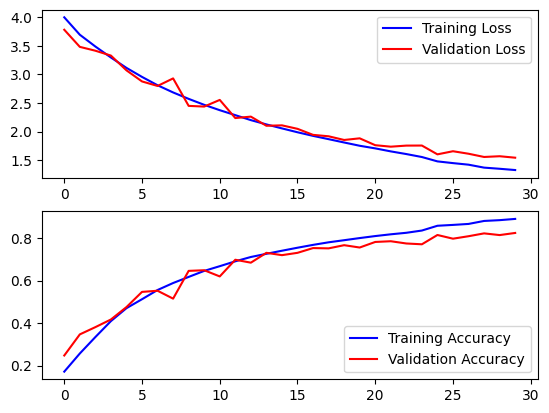

In [8]:
# Visualize training and validation performance
f,ax=plt.subplots(2,1)

# Plot training and validation loss
ax[0].plot(history.history['loss'], color='b',label='Training Loss')
ax[0].plot(history.history['val_loss'],color='r',label='Validation Loss')
ax[0].legend()

# Plot training and validation accuracy
ax[1].plot(history.history['accuracy'],color='b',label='Training Accuracy')
ax[1].plot(history.history['val_accuracy'],color='r',label='Validation Accuracy')
ax[1].legend()

# Evaluate the model's performance on the test set

In [9]:
# Let's evaluate the model's performance on the test set
result = my_model.evaluate(X_test, y_test)

313/313 [==============================] - 3s 7ms/step - loss: 1.5156 - accuracy: 0.8373


In [10]:
# Show the model's performance
print(my_model.metrics_names)
print("Loss and accuracy on the test set: loss = {}, accuracy = {}".format(result[0],result[1]))

['loss', 'accuracy']
Loss and accuracy on the test set: loss = 1.5156400203704834, accuracy = 0.8373000025749207


In [11]:
# This is to delete all saved models (*.hdf5) in the current directory
'''import os
import glob
# Get a list of all the file paths that ends with .txt from in specified directory
fileList = glob.glob('*.hdf5')
# Iterate over the list of filepaths & remove each file.
for filePath in fileList:
  try:
    os.remove(filePath)
  except:
    print("Error while deleting file : ", filePath)'''

'import os\nimport glob\n# Get a list of all the file paths that ends with .txt from in specified directory\nfileList = glob.glob(\'*.hdf5\')\n# Iterate over the list of filepaths & remove each file.\nfor filePath in fileList:\n  try:\n    os.remove(filePath)\n  except:\n    print("Error while deleting file : ", filePath)'